# TP de Regresión — Predicción de precios de casas (Boston)
### Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA - UNR)

**Integrantes:** Aguirre, Gambande, Paladini



---
## 1. Configuración del entorno y carga de datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización (consistencia entre gráficos)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # semilla fija para reproducibilidad en todo el notebook

In [2]:
# Carga del dataset
df = pd.read_csv('data/house-prices-tp.csv') 

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


---
## 2. Inspección del dataset

In [3]:
# Tipos de datos y nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [4]:
# Separación de variables por tipo
# CHAS es una dummy, hay que tratarla como categórica

cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas.remove('MEDV')  # varaible target se analiza aparte
col_categorica = 'CHAS'
if col_categorica in cols_numericas:
    cols_numericas.remove(col_categorica)

print(f'Variables numéricas continuas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variable categórica (dummy): {col_categorica}')
print('Variable target: MEDV')

Variables numéricas continuas (12): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Variable categórica (dummy): CHAS
Variable target: MEDV


---
## 3. Análisis descriptivo

Medidas de tendencia central, dispersión, sesgo y curtosis para cada variable numérica.

- Esto permite entender rango de variación y forma de la distribución de cada variable antes de decidir
transformaciones o tratamiento de outliers.

In [5]:
desc = df[cols_numericas + ['MEDV']].describe().T
# el .T transpone la tabla para ver una fila por variable con sus datos estadisticos

desc['mediana'] = df[cols_numericas + ['MEDV']].median()

desc['sesgo'] = df[cols_numericas + ['MEDV']].skew()
# Mide qué tan asimétrica es la distribución de cada variable: 
# 0 = simétrica, positivo = cola hacia la derecha, negativo = cola hacia la izquierda

desc['curtosis'] = df[cols_numericas + ['MEDV']].kurtosis()
# Mide qué tan pesadas son las colas de la distribución comparado con una normal
# valores altos indican más outliers/valores extremos: leptocurtica (colas pesadas, pico mas pronunciado).
# valores bajos indican una distribución más achatada: platicurtica (colas livianas, distribucion mas aplanada).

desc[['mean', 'mediana', 'std', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']]

,mean,mediana,std,min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.845517,0.315330,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,13.197175,0.000000,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,11.218725,9.690000,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
NOX,0.560050,0.538000,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,6.291839,6.208000,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,67.632303,76.500000,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,3.944102,3.340107,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,9.699379,5.000000,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,409.575089,335.000000,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504
PTRATIO,18.429904,19.000000,2.194759,12.60000,17.00000,19.000000,20.200000,22.0000,-0.787238,-0.304842


Las variables CRIM, B, ZN, DIS y MEDV presentan sesgo marcado (|sesgo| > 1). CRIM y B son las más extremas: 
- **CRIM** tiene cola derecha muy larga y además tiene una curtosis muy elevada (15.25) (leptocurtica), lo que indica una distribución con colas muy pesada 
- mientras que **B** presenta un sesgo negativo fuerte y curtosis alta (4.50) (leptocurtica).
- Estas variables son candidatas a una **transformación logarítmica** antes de entrenar el modelo de regresión, ya que la regresión lineal asume relaciones lineales y errores homocedásticos, y una distribución muy sesgada puede violar esos supuestos.
- MEDV al ser el target también sugiere evaluar una transformación logarítmica, aunque eso complica la interpretación

(array([374.,  40.,  26.,  22.,  16.,   7.,   7.,   4.,   6.,   2.,   4.,
          1.,   2.,   1.,   2.,   3.,   1.,   1.,   1.,   1.,   0.,   1.,
          2.,   0.,   2.,   2.,   3.,   0.,   0.,   2.]),
 array([6.32000000e-03, 2.97198267e+00, 5.93764533e+00, 8.90330800e+00,
        1.18689707e+01, 1.48346333e+01, 1.78002960e+01, 2.07659587e+01,
        2.37316213e+01, 2.66972840e+01, 2.96629467e+01, 3.26286093e+01,
        3.55942720e+01, 3.85599347e+01, 4.15255973e+01, 4.44912600e+01,
        4.74569227e+01, 5.04225853e+01, 5.33882480e+01, 5.63539107e+01,
        5.93195733e+01, 6.22852360e+01, 6.52508987e+01, 6.82165613e+01,
        7.11822240e+01, 7.41478867e+01, 7.71135493e+01, 8.00792120e+01,
        8.30448747e+01, 8.60105373e+01, 8.89762000e+01]),
 <BarContainer object of 30 artists>)

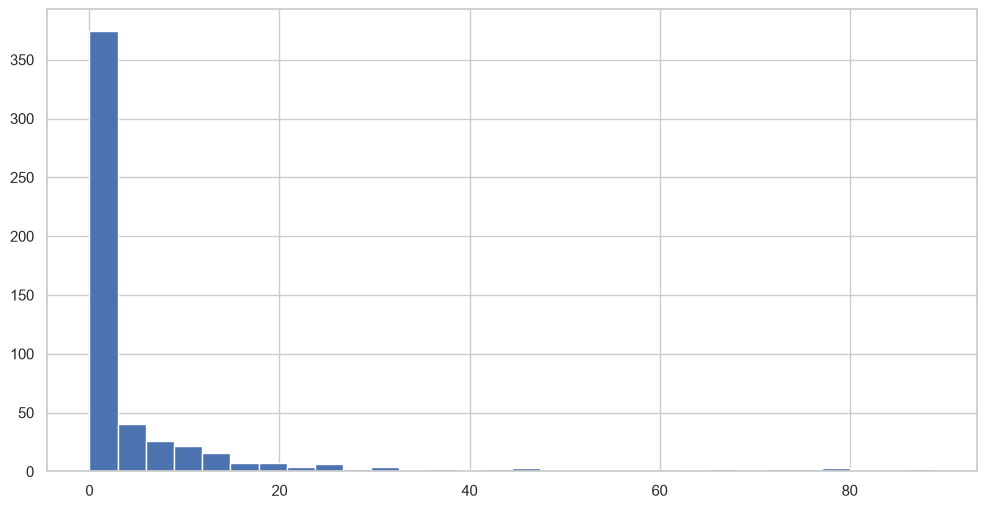

In [6]:
plt.hist(df["CRIM"], bins=30)

(array([ 10.,   6.,   4.,   4.,   2.,   3.,   6.,   6.,   2.,   3.,   1.,
          1.,   2.,   2.,   2.,   3.,   1.,   2.,   5.,   4.,   1.,   3.,
          6.,   6.,   7.,   9.,  18.,  17.,  61., 337.]),
 array([3.20000000e-01, 1.35393333e+01, 2.67586667e+01, 3.99780000e+01,
        5.31973333e+01, 6.64166667e+01, 7.96360000e+01, 9.28553333e+01,
        1.06074667e+02, 1.19294000e+02, 1.32513333e+02, 1.45732667e+02,
        1.58952000e+02, 1.72171333e+02, 1.85390667e+02, 1.98610000e+02,
        2.11829333e+02, 2.25048667e+02, 2.38268000e+02, 2.51487333e+02,
        2.64706667e+02, 2.77926000e+02, 2.91145333e+02, 3.04364667e+02,
        3.17584000e+02, 3.30803333e+02, 3.44022667e+02, 3.57242000e+02,
        3.70461333e+02, 3.83680667e+02, 3.96900000e+02]),
 <BarContainer object of 30 artists>)

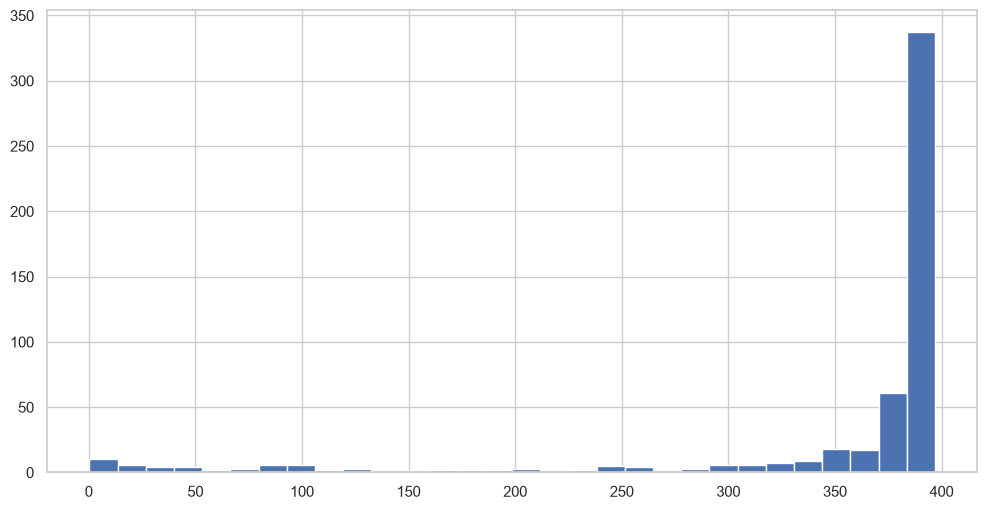

In [7]:
plt.hist(df["B"], bins=30)

- **RAD**:los percentiles de la tabla muestran un salto brusco entre la mediana (5.0) y el percentil 75 (23.63), lo cual no es compatible con una distribución gradual.

In [8]:
# Verificación del patrón bimodal de RAD a partir de los percentiles
df['RAD'].value_counts().sort_index()

RAD
1.000000      20
1.307128       1
2.000000      24
2.402424       1
2.573615       1
3.000000      38
3.056548       1
4.000000     110
4.528569       1
4.811748       1
5.000000     115
6.000000      26
6.850123       1
7.000000      17
8.000000      24
10.168701      1
10.554892      1
14.195528      1
14.638330      1
15.239579      1
17.000150      1
17.110181      1
17.164570      1
18.177503      1
19.266891      1
20.416908      1
21.900776      1
22.069511      1
22.328313      1
23.510213      1
24.000000    132
Name: count, dtype: int64

- Se confirma que RAD es bimodal: la mayoría de las observaciones se concentra en valores bajos (1 a 8), y un segundo grupo grande se concentra directamente en el valor máximo (24), sin observaciones intermedias
- Esto se va a poder observar en un histograma

(array([ 21.,  26.,  39., 111., 116.,  26.,  18.,  24.,   0.,   1.,   1.,
          0.,   0.,   0.,   2.,   1.,   0.,   3.,   1.,   1.,   0.,   1.,
          2.,   1., 133.]),
 array([ 1.  ,  1.92,  2.84,  3.76,  4.68,  5.6 ,  6.52,  7.44,  8.36,
         9.28, 10.2 , 11.12, 12.04, 12.96, 13.88, 14.8 , 15.72, 16.64,
        17.56, 18.48, 19.4 , 20.32, 21.24, 22.16, 23.08, 24.  ]),
 <BarContainer object of 25 artists>)

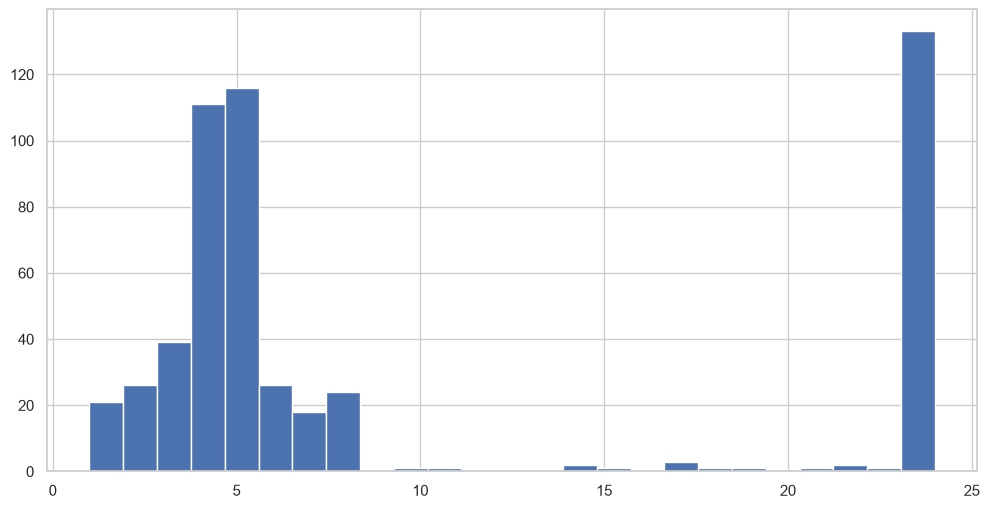

In [9]:
plt.hist(df["RAD"], bins=25)

In [10]:
# Distribución de la variable dummy CHAS
df[col_categorica].value_counts(dropna=False)

CHAS
0.0    485
1.0     48
NaN     23
Name: count, dtype: int64

---
## 4. Análisis y decisión sobre datos faltantes


In [11]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
PTRATIO,28,5.04
RAD,28,5.04
NOX,24,4.32
AGE,24,4.32
CHAS,23,4.14
CRIM,23,4.14
LSTAT,22,3.96
B,22,3.96
ZN,22,3.96
RM,21,3.78


- Cada columna tiene entre 2.70% y 5.04% de nulos, por encima del umbral del 2.5% para descartar.

- MCAR -> la falta de dato es pura casualidad
- MAR -> la falta del dato depende de otras varaibles observadas, eliminar aca sesga, imputar con KNN
- MNAR -> la falta depende del propio valor faltante

In [12]:
# Chequeo: los nulos están relacionados con alguna otra variable?
tiene_nulo = df.isnull().any(axis=1)

print('CRIM mediana en filas CON algún nulo:', df.loc[tiene_nulo, 'CRIM'].median())
print('CRIM mediana en filas SIN nulos:', df.loc[~tiene_nulo, 'CRIM'].median())

CRIM mediana en filas CON algún nulo: 45.877735005789845
CRIM mediana en filas SIN nulos: 0.25651


se detectó que la falta de datos no es aleatoria: la mediana de CRIM en filas con algún nulo es 45.88, muy superior a 0.26 en filas completas. Esto indica que 
los nulos se concentran en zonas de alta criminalidad, por lo que eliminarlos sesgaría el dataset.

In [13]:
# Chequeo de nulos para ver si están relacionados con otras variables
tiene_nulo = df.isnull().any(axis=1)

comparacion = pd.DataFrame({
    'mediana_con_nulo': df.loc[tiene_nulo, df.columns].median(),
    'mediana_sin_nulo': df.loc[~tiene_nulo, df.columns].median()})
comparacion

,mediana_con_nulo,mediana_sin_nulo
CRIM,45.877735,0.25651
ZN,51.489693,0.00000
INDUS,12.533122,9.69000
CHAS,0.000000,0.00000
NOX,0.686619,0.53800
RM,6.004147,6.20850
AGE,41.922414,77.50000
DIS,5.731208,3.20745
RAD,14.938955,5.00000
TAX,439.526576,330.00000


- la falta de datos no es aleatoria, al comparar la mediana de cada variable entre filas con y sin nulos, casi todas muestran diferencias marcadas 
- (CRIM: 45.88 vs 0.26; ZN: 51.49 vs 0.00; B: 189.3 vs 391.4; RAD, TAX y LSTAT también más altos 
en filas con nulos). 
- Esto sugiere que los nulos se concentran en un perfil particular de zona 
(alta criminalidad, baja zonificación residencial, más impuestos), no distribuido al azar. 
- Eliminar esas filas sesgaría el dataset descartando ese tipo de zonas.

Se observa una asociación entre la presencia de nulos y el perfil de la zona: las filas con datos faltantes tienden a corresponder a barrios de mayor criminalidad, menor zonificación residencial y mayores impuestos, mientras que las filas completas tienden a zonas con perfil opuesto. Esto permite descartar que la falta de datos sea completamente aleatoria (MCAR), lo cual justifica la decisión de imputar en lugar de eliminar esas filas.

**Se decidió imputar usando KNN (k=5) para las variables numéricas, ya que aprovecha el 
parecido entre filas en lugar de imponer un único valor global. La variable CHAS (categórica) se 
imputó con la moda.**

Como KNN es sensible a las unidades de los datos hay que hacer un escalado previamente.

Para el escalado previo a la imputación con KNN se utilizó RobustScaler en lugar de StandardScaler, 
porque que variables como CRIM y B presentan outliers marcados (evidenciado por su sesgo y curtosis 
elevados), y StandardScaler es sensible a estos valores extremos al calcular media y desviación estándar.

**Aclaración:** el código que aplica esta imputación se ejecuta más adelante, recién después de dividir los datos de train y test, para que el imputador se ajuste solo con datos de entrenamiento y no haya data leakage hacia el conjunto de test.

---
## 5. Visualización de datos

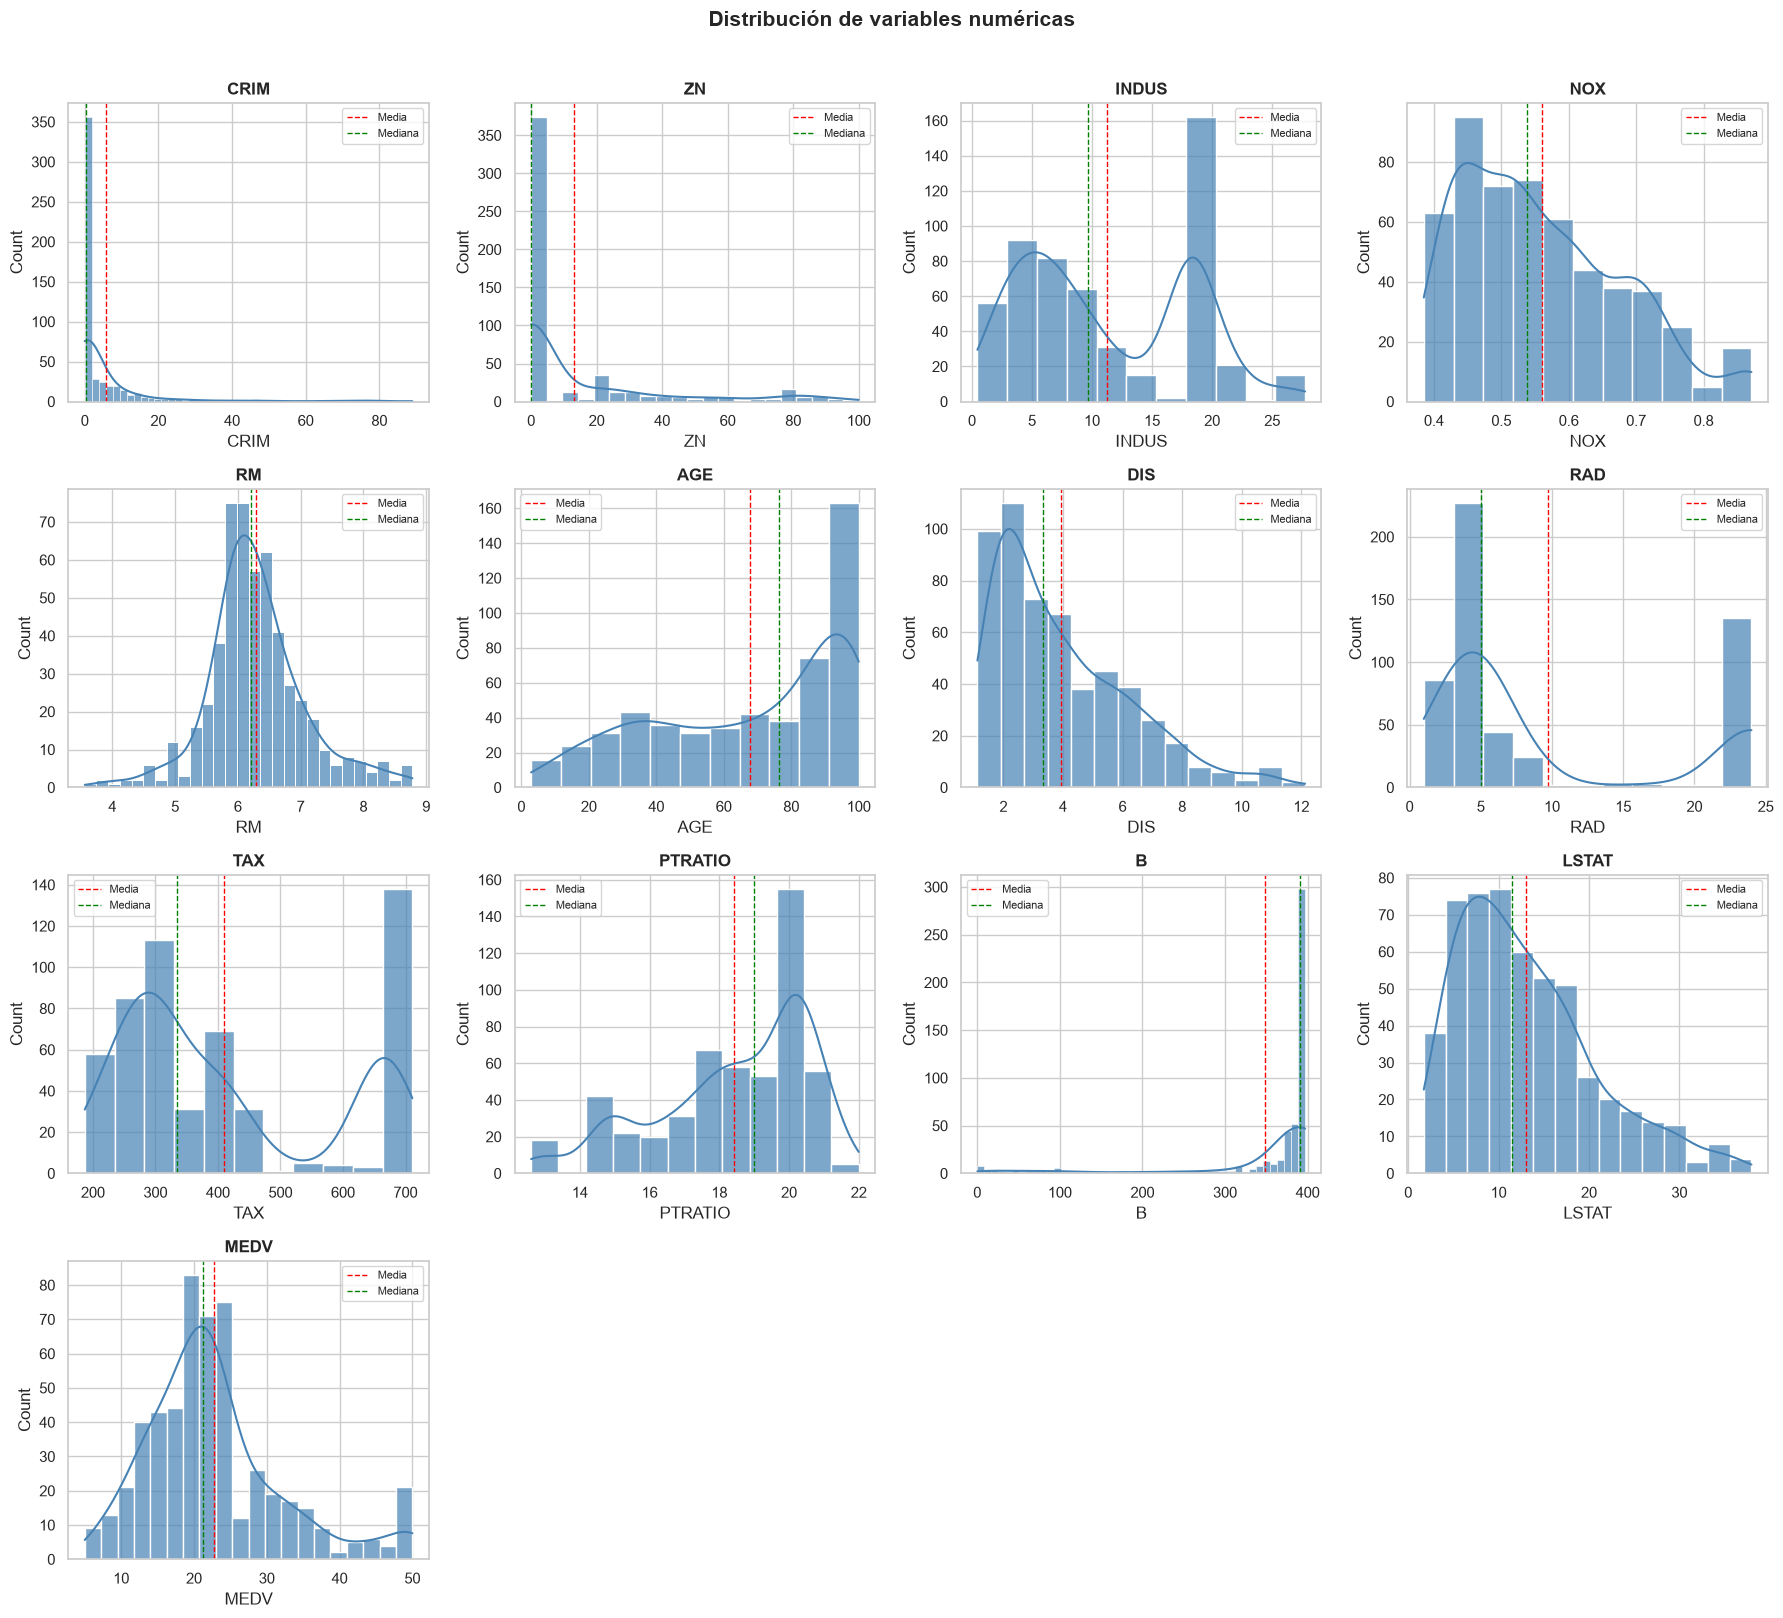

In [14]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman visualmente:

- **Sesgo positivo marcado (cola derecha larga):** CRIM, ZN, y en menor medida LSTAT y DIS. 
  La mayoría de las observaciones se concentra en valores bajos, con una cola de casos extremos 
  poco frecuentes — coincide con los valores de sesgo calculados antes (CRIM: 3.75, ZN: 1.96).

- **Sesgo negativo (cola izquierda):** B y AGE. En B, la mayoría de los valores se acumula cerca 
  del máximo, con pocos casos de valores bajos (sesgo: -2.40).

- **Distribución bimodal (dos grupos separados, sin observaciones intermedias):** RAD y TAX. Se 
  observan dos concentraciones claras: un grupo con valores bajos/medios y otro grupo grande 
  agrupado directamente en el valor máximo (RAD=24, TAX=666). Esto ya se había anticipado al revisar los percentiles de RAD (salto brusco entre la mediana y el percentil 75).

- **Distribución aproximadamente simétrica/campana:** RM es la que más se acerca a una distribución 
  normal (sesgo: 0.37).

- **MEDV (target):** presenta sesgo positivo moderado (1.06), con un pico marcado cerca de 50.
Esto es un posible indicio de que los valores de MEDV fueron truncados en 50.

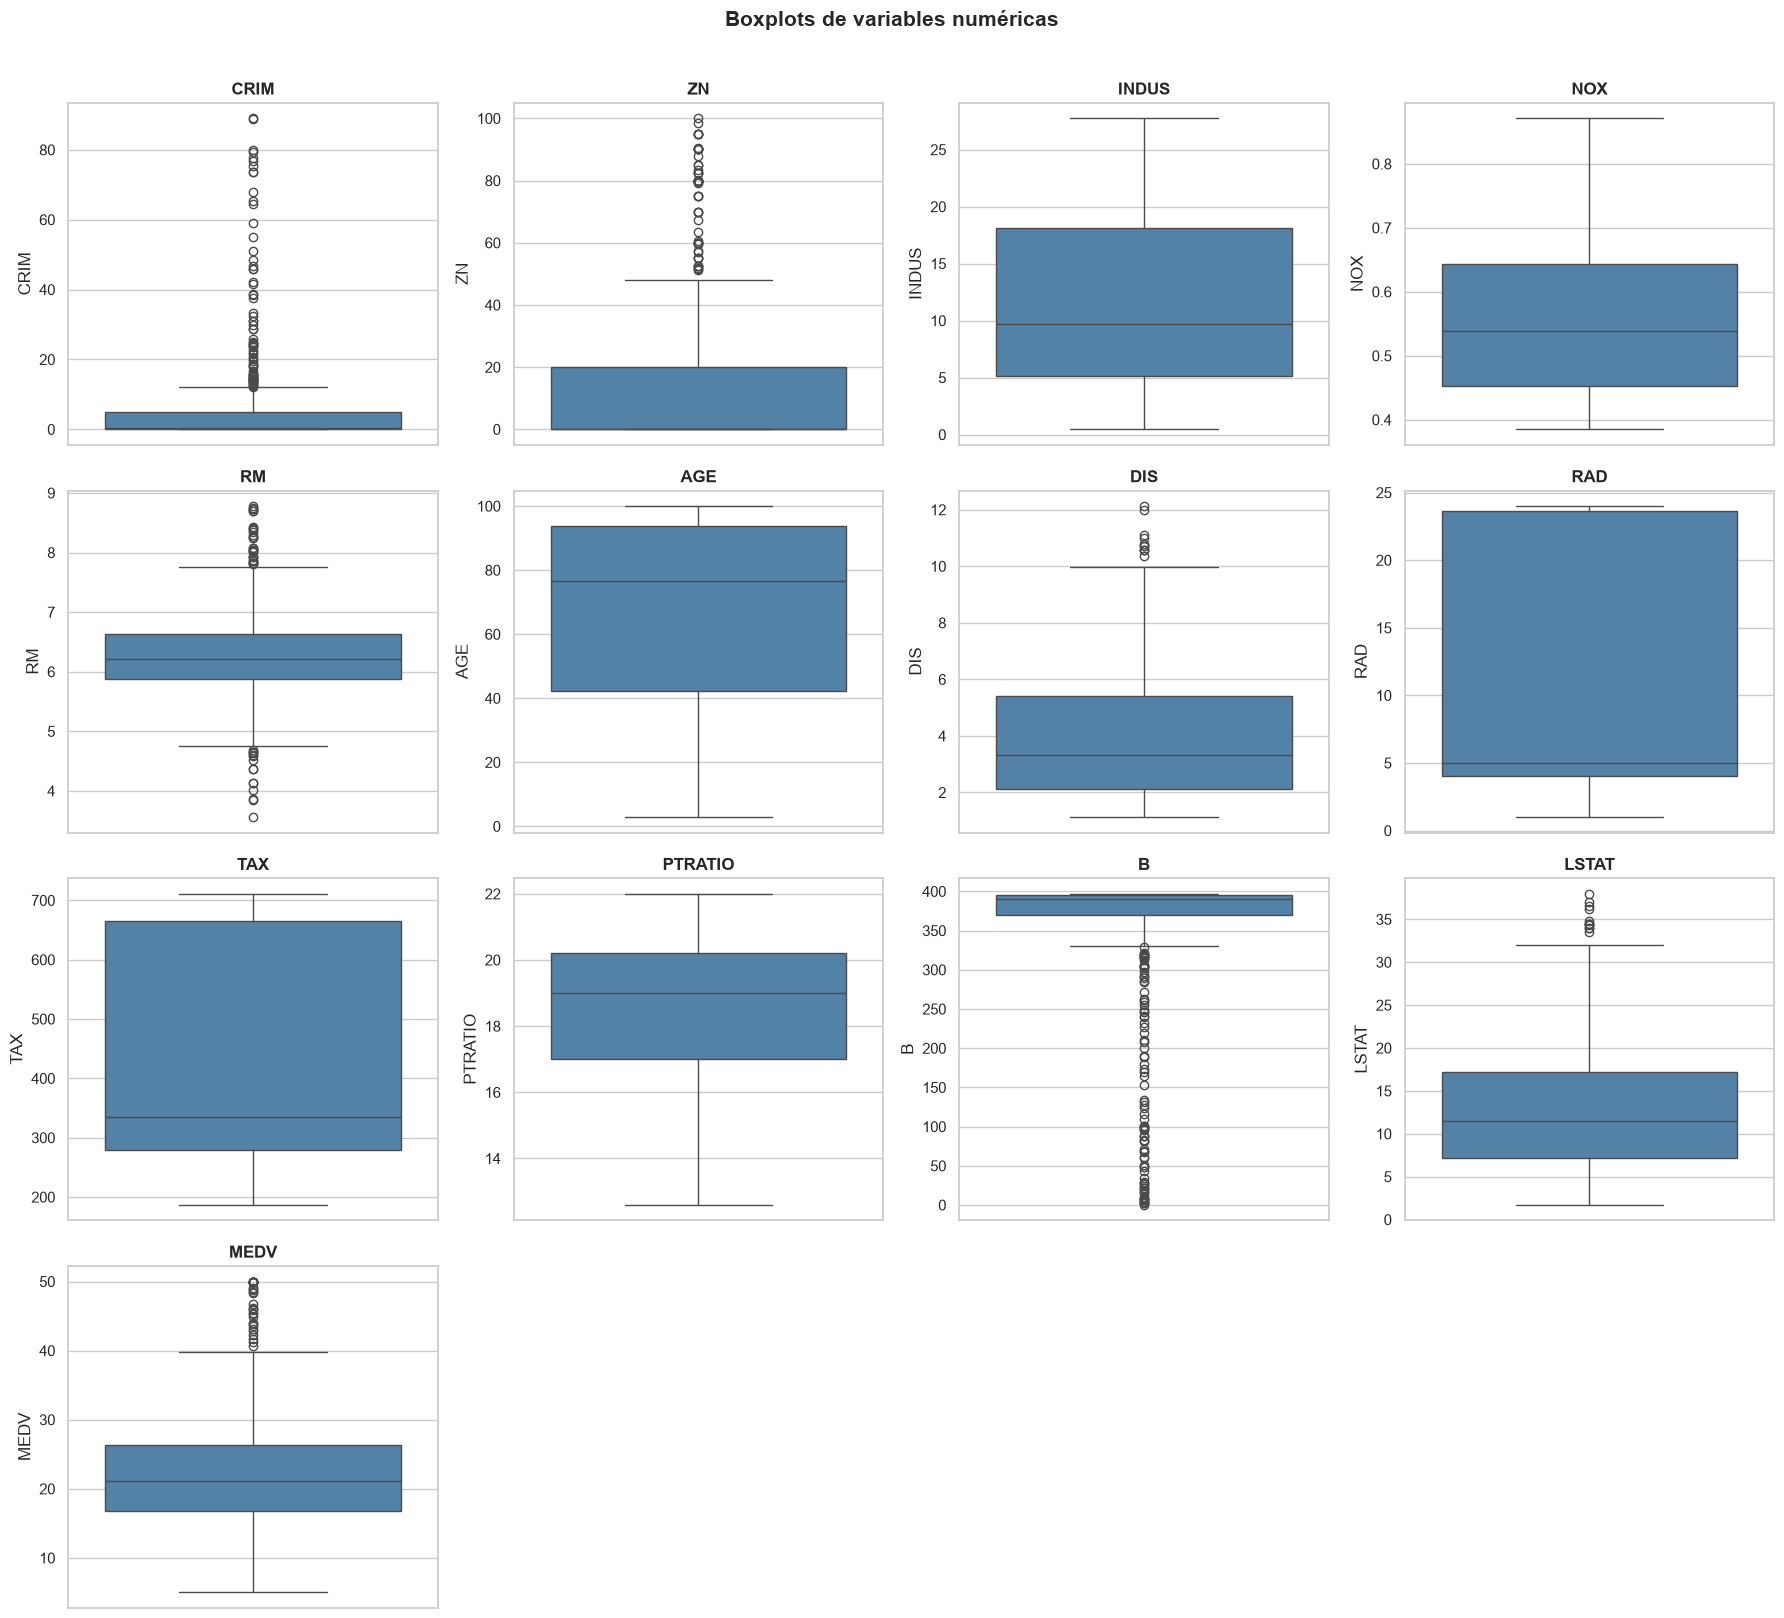

In [15]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Outliers:** se optó por NO eliminar los outliers detectados con el método IQR, 
dado que en variables como CRIM y B corresponden a una subpoblación real (zonas de alta 
criminalidad), la misma identificada en el análisis de datos faltantes. Eliminarlos introduciría 
el mismo sesgo que se buscó evitar al imputar en lugar de eliminar los nulos.

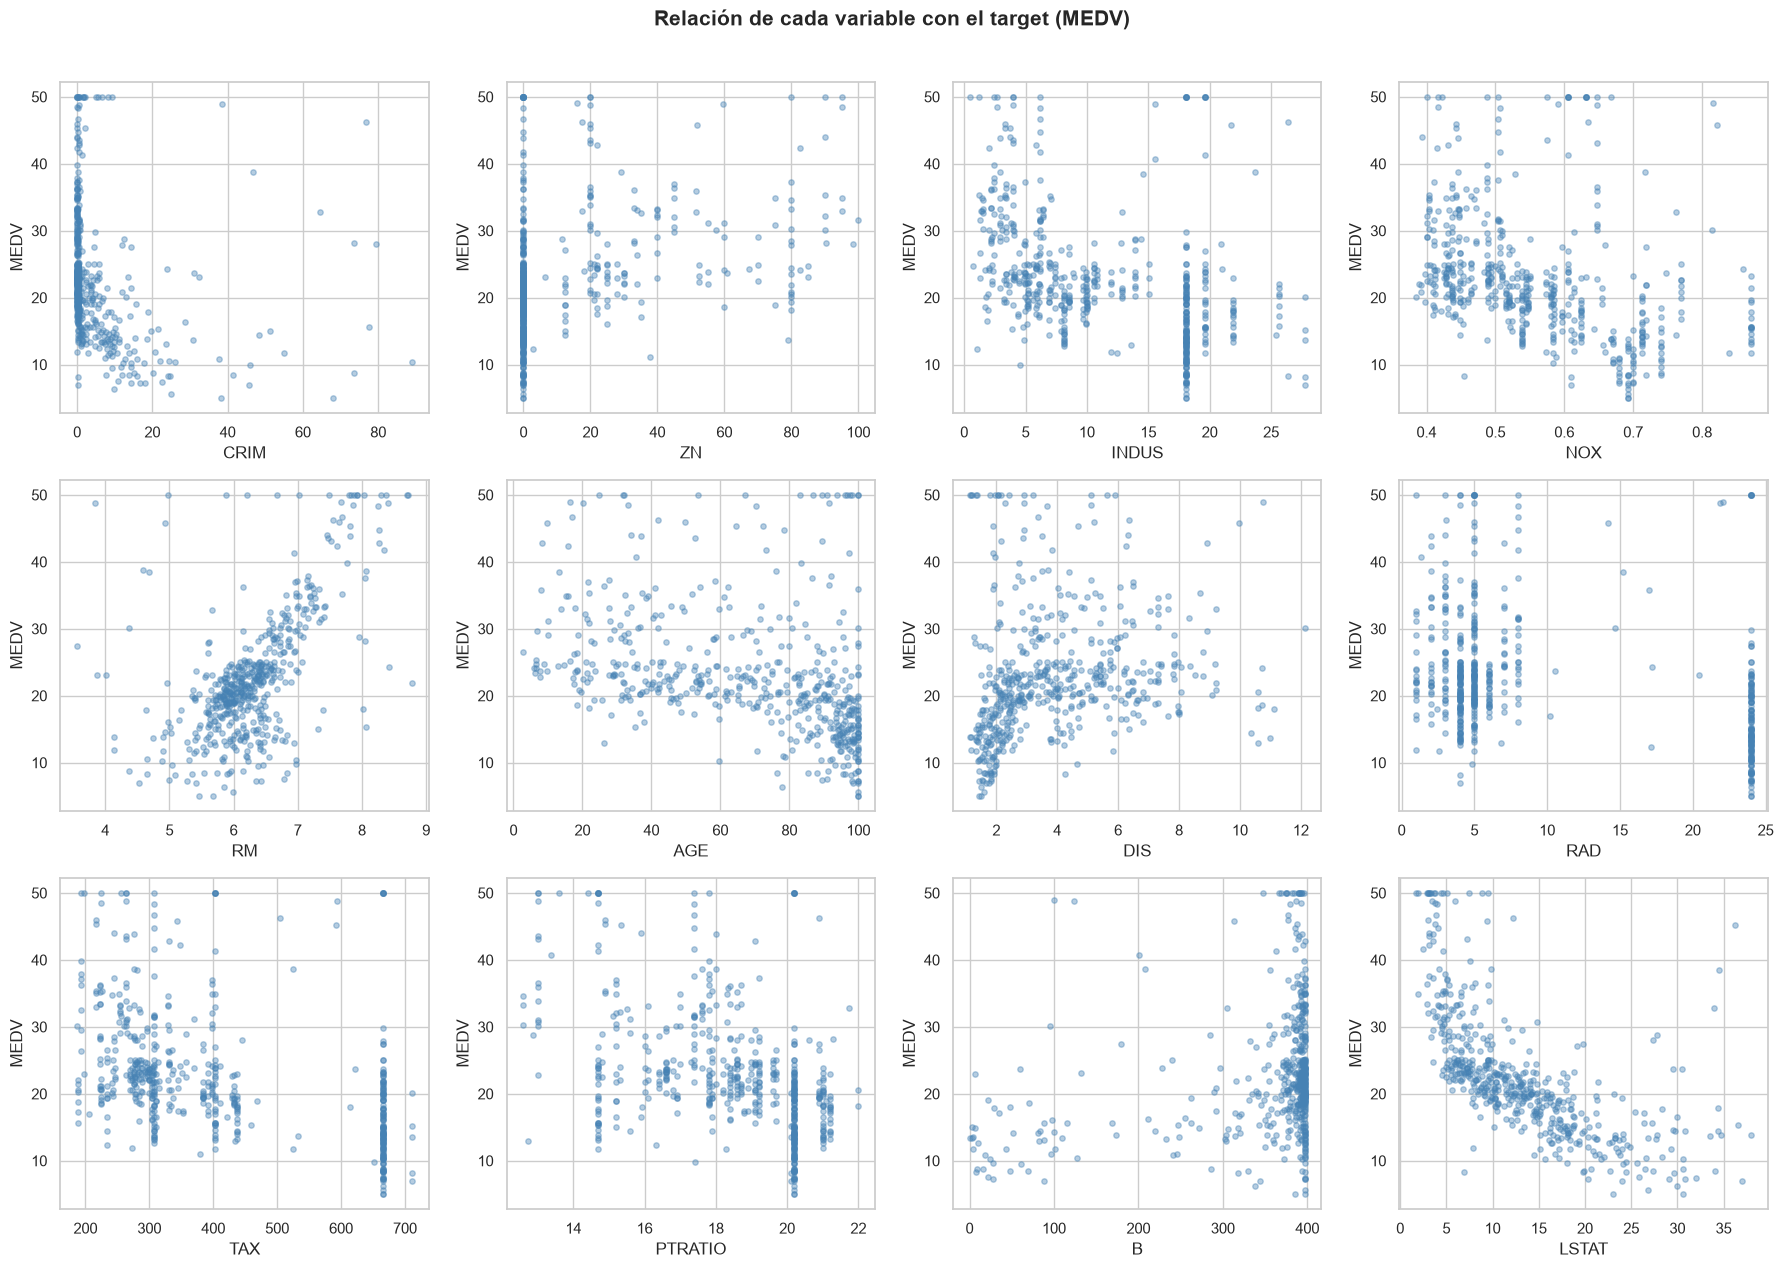

In [ ]:
# Scatterplots de cada variable contra el target MEDV
# da una primera idea de qué variables tienen relación lineal fuerte con el precio (MEDV)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    ax.scatter(df[col], df['MEDV'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MEDV')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación de cada variable con el target (MEDV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Patrones:

- **RM** muestra una relación positiva: a mayor número de habitaciones 
  promedio, mayor precio, tendencia ascendente bastante definida.
- **LSTAT** muestra una relación negativa marcada, pero con una forma curva: el precio cae fuerte para valores bajos de LSTAT y despues la caída se aplana. 
Esto sugiere que una transformación no lineal podría representar mejor esta relación.

- Variables como CRIM, DIS, CHAS y B se ven como nubes de puntos más dispersas, sin una tendencia lineal clara.

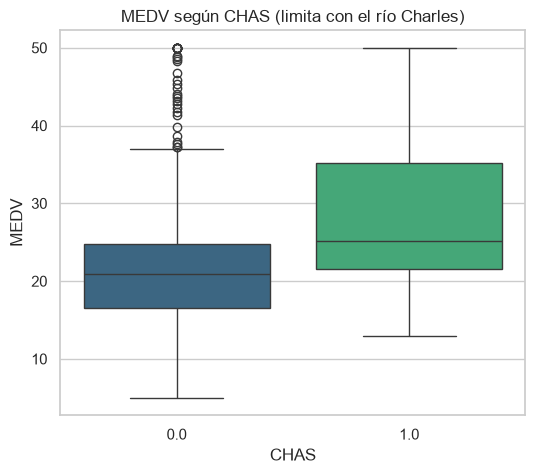

In [ ]:
# MEDV según la variable dummy CHAS (para determinar si limitar con el río impacta en el precio)
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x=col_categorica, y='MEDV', palette='viridis')
plt.title('MEDV según CHAS (limita con el río Charles)')
plt.show()

El boxplot de MEDV según CHAS muestra que las zonas que limitan con el rio (CHAS=1) 
tienden a tener precios más altos (mediana 25.1) que las que no limitan (mediana 20.9). Sin 
embargo, el grupo CHAS=1 representa una fracción pequeña del dataset (45 filas)

---
## 6. Codificación de variables categóricas

`CHAS` es la única variable categórica del dataset y ya viene codificada como dummy (0/1),
por lo tanto no requiere un encoding adicional.

---
## 7. Matriz de correlación

In [18]:
corr = df.corr(method='pearson')
corr.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,0.06,0.28,0.20,0.38,-0.04,0.18,-0.15,0.52,0.43,0.25,-0.44,0.38,-0.23
ZN,0.06,1.00,-0.47,0.02,-0.42,0.24,-0.57,0.65,-0.27,-0.29,-0.35,0.08,-0.34,0.36
INDUS,0.28,-0.47,1.00,0.10,0.73,-0.33,0.60,-0.60,0.57,0.69,0.37,-0.32,0.52,-0.42
CHAS,0.20,0.02,0.10,1.00,0.12,0.01,0.03,-0.04,0.03,-0.04,-0.11,-0.06,0.00,0.21
NOX,0.38,-0.42,0.73,0.12,1.00,-0.25,0.65,-0.63,0.60,0.64,0.18,-0.40,0.55,-0.36
RM,-0.04,0.24,-0.33,0.01,-0.25,1.00,-0.20,0.19,-0.21,-0.23,-0.33,0.09,-0.52,0.59
AGE,0.18,-0.57,0.60,0.03,0.65,-0.20,1.00,-0.72,0.42,0.49,0.25,-0.20,0.55,-0.40
DIS,-0.15,0.65,-0.60,-0.04,-0.63,0.19,-0.72,1.00,-0.46,-0.48,-0.23,0.16,-0.42,0.22
RAD,0.52,-0.27,0.57,0.03,0.60,-0.21,0.42,-0.46,1.00,0.87,0.46,-0.43,0.47,-0.34
TAX,0.43,-0.29,0.69,-0.04,0.64,-0.23,0.49,-0.48,0.87,1.00,0.44,-0.41,0.51,-0.44


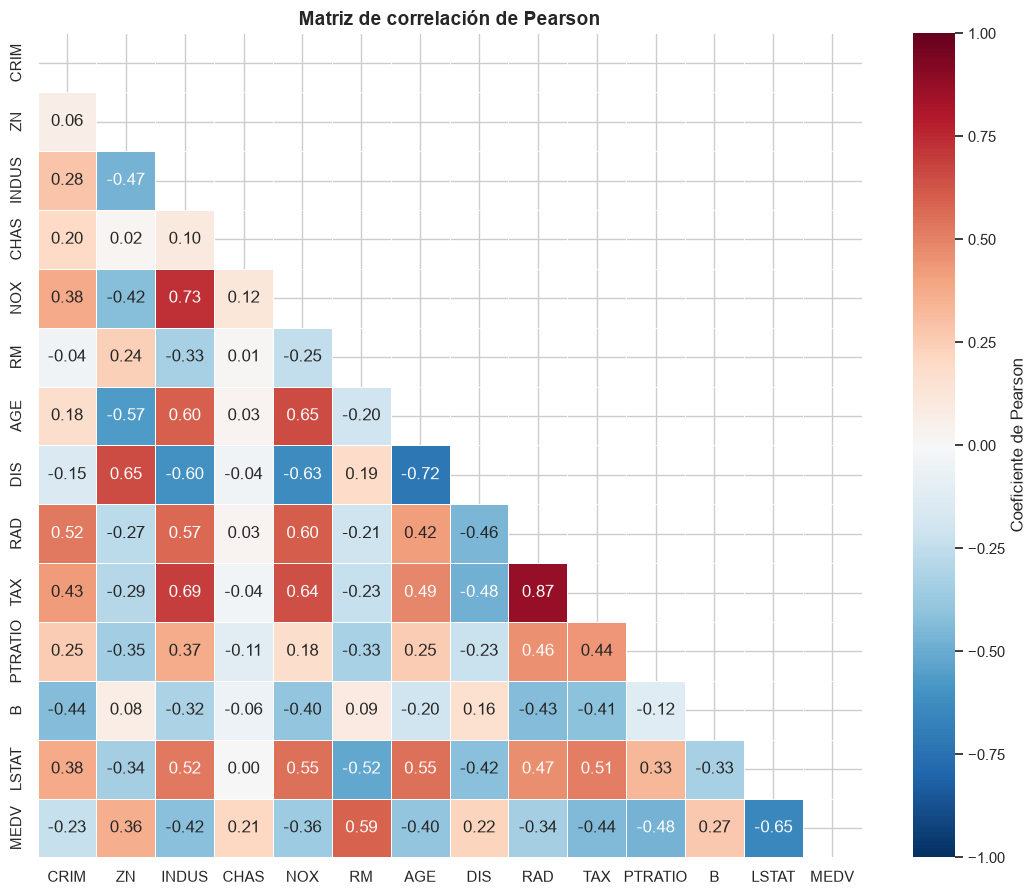

In [19]:

mask = np.triu(np.ones_like(corr, dtype=bool)) # solo grafica un lado de la matriz
plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title('Matriz de correlación de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlación con el target (MEDV):**

Las variables con correlación más fuerte con MEDV son LSTAT (r=-0.65) y RM (r=0.59), consistente 
con lo observado en los scatterplots de la sección anterior. Le siguen PTRATIO (r=-0.48), TAX 
(r=-0.44) e INDUS (r=-0.42) con correlación moderada. Variables como CRIM (r=-0.23), DIS (r=0.22) 
y CHAS (r=0.21) muestran correlación lineal débil con el precio, aunque esto no descarta que 
aporten valor predictivo de forma no lineal.

**Colinealidad:**

Se identificaron tres pares de variables con correlación fuerte entre sí (|r| >= 0.7):

- RAD y TAX (r=0.87): la más alta del dataset. Coincide con el patrón bimodal detectado antes en 
  ambas variables, que comparten el mismo subconjunto de zonas con RAD=24 y TAX=666.

- INDUS y NOX (r=0.73): zonas con más superficie industrial tienden a tener mayor concentración 
  de óxidos de nitrógeno.

- AGE y DIS (r=-0.72): zonas con viviendas más antiguas tienden a estar más cerca de los centros 
  de empleo.

Esta colinealidad es relevante porque la regresión lineal asume que los predictores son 
independientes entre sí.

**Duplicados:** no se encontraron filas duplicadas en el dataset, por lo que no fue 
necesaria ninguna decisión de eliminación en este aspecto.

In [28]:
# Chequeo de filas duplicadas
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados} de {len(df)} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 0 de 556 (0.00%)


---
## 8. Detección de outliers (método IQR)

In [25]:
cols_iqr = [c for c in df.columns if c != 'CHAS']

Q1 = df[cols_iqr].quantile(0.25)
Q3 = df[cols_iqr].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((df[cols_iqr] < limite_inferior) | (df[cols_iqr] > limite_superior)).sum()
porcentaje_outliers = (outliers / len(df) * 100).round(2)

print('Outliers por variable:')
print(outliers)
print()
print('Porcentaje de outliers por variable:')
print(porcentaje_outliers)

Outliers por variable:
CRIM       69
ZN         60
INDUS       0
NOX         0
RM         45
AGE         0
DIS        11
RAD         0
TAX         0
PTRATIO     0
B          91
LSTAT      12
MEDV       37
dtype: int64

Porcentaje de outliers por variable:
CRIM       12.41
ZN         10.79
INDUS       0.00
NOX         0.00
RM          8.09
AGE         0.00
DIS         1.98
RAD         0.00
TAX         0.00
PTRATIO     0.00
B          16.37
LSTAT       2.16
MEDV        6.65
dtype: float64


Se excluye CHAS de este análisis porque al ser una variable binaria el método IQR no es aplicable

Las variables con mayor proporción de outliers son B, CRIM y ZN, coherente con el sesgo marcado 
y la curtosis alta detectados en el análisis descriptivo para estas tres.

Como se justificó en la sección de datos faltantes, los outliers de CRIM y B corresponden a una 
subpoblación real del dataset (zonas de alta criminalidad), por lo que no se eliminan.

---
## 9. División train / test

**Nota:** para evitar data leakage, la imputación con KNN (decidida y 
justificada en la sección de datos faltantes) se aplica recién acá, **después** del split, 
ajustando el imputador únicamente con los datos de entrenamiento. Así el conjunto de 
test nunca influye en cómo se completan los valores faltantes de train, ni viceversa.

In [ ]:
# Split ANTES de imputar y de estandarizar (evita data leakage en ambos pasos).
# nulos: se imputan recien despues de dividir el dataset

X = df[cols_numericas + [col_categorica]]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()} | Nulos en X_test: {X_test.isnull().sum().sum()}')
print(f'Nulos en y_train: {y_train.isnull().sum()} | Nulos en y_test: {y_test.isnull().sum()}')


Train: 444 filas | Test: 112 filas
Nulos en X_train: 240 | Nulos en X_test: 45
Nulos en y_train: 19 | Nulos en y_test: 2


In [ ]:
from sklearn.preprocessing import RobustScaler

# Variables numericas continuas + target se imputan juntas con KNN
cols_num_target = cols_numericas + ['MEDV']

train_num_target = X_train[cols_numericas].copy()
train_num_target['MEDV'] = y_train

test_num_target = X_test[cols_numericas].copy()
test_num_target['MEDV'] = y_test

# Escalar (RobustScaler) fit solo con train
scaler_temp = RobustScaler()

train_scaled = pd.DataFrame(scaler_temp.fit_transform(train_num_target),columns=cols_num_target, index=train_num_target.index)

test_scaled = pd.DataFrame(scaler_temp.transform(test_num_target),columns=cols_num_target, index=test_num_target.index)



In [ ]:
from sklearn.impute import KNNImputer

# Imputar con KNN - fit solo en train, transform en train y test
imputer = KNNImputer(n_neighbors=5)

train_imp_scaled = pd.DataFrame(imputer.fit_transform(train_scaled),columns=cols_num_target, index=train_num_target.index)

test_imp_scaled = pd.DataFrame(imputer.transform(test_scaled),columns=cols_num_target, index=test_num_target.index)


# Volver a la escala original (inverse_transform)
train_imputado = pd.DataFrame(scaler_temp.inverse_transform(train_imp_scaled),columns=cols_num_target, index=train_num_target.index)
test_imputado = pd.DataFrame(scaler_temp.inverse_transform(test_imp_scaled),columns=cols_num_target, index=test_num_target.index)

# Reemplazar en X_train/X_test/y_train/y_test los valores ya imputados
X_train[cols_numericas] = train_imputado[cols_numericas]
y_train = train_imputado['MEDV']

X_test[cols_numericas] = test_imputado[cols_numericas]
y_test = test_imputado['MEDV']


In [ ]:
# CHAS varaible categorica, imputar con la moda
moda_chas_train = X_train['CHAS'].mode()[0]
X_train['CHAS'] = X_train['CHAS'].fillna(moda_chas_train)
X_test['CHAS'] = X_test['CHAS'].fillna(moda_chas_train)

In [ ]:
# Verificacion de nulos

print('Nulos restantes - X_train:', X_train.isnull().sum().sum(), '| X_test:', X_test.isnull().sum().sum())
print('Nulos restantes - y_train:', y_train.isnull().sum(), '| y_test:', y_test.isnull().sum())


Nulos restantes - X_train: 0 | X_test: 0
Nulos restantes - y_train: 0 | y_test: 0


- Fit en train → transform en test: la información fluye en un solo sentido (train → test). Test nunca influye en nada que se use para procesar train (no leakage).
- Fit en train + test juntos (imputar/escalar antes del split): la información fluye en ambos sentidos. Un valor de test puede terminar afectando cómo se procesa una fila de train, y viceversa (leakage).

In [ ]:
# Transformación logarítmica de CRIM y DIS (sesgo positivo). No elimina outliers solo comprime su escala.
# B se deja sin transformar: tiene sesgo negativo, y log empeora ese tipo de sesgo.

for col in ['CRIM', 'DIS']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# ZN: 73.5% de valores en 0 (zero-inflada), log1p mejora poco -> se deja sin transformar
# MEDV: es el target, se evaluará en la sección de modelado (punto 4), no acá


---
## 10. Estandarización de variables numéricas

Se utilizó StandardScaler (no RobustScaler) para este paso, ya que los modelos que se entrenan a 
continuación (regresión lineal, Ridge, Lasso) están calibrados asumiendo variables con media 0 y 
desvío estándar 1.

In [ ]:
scaler = StandardScaler()

# Fit sobre sobre train, transform sobre train y test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]  # verificación: media ~0, std ~1 en train

,mean,std
CRIM,2.600522e-17,1.001128
ZN,3.200643e-17,1.001128
INDUS,2.720547e-16,1.001128
NOX,8.801768e-17,1.001128
RM,-7.601527e-17,1.001128
AGE,-1.600321e-17,1.001128
DIS,-3.440691e-16,1.001128
RAD,-1.740350e-16,1.001128
TAX,4.090822e-16,1.001128
PTRATIO,1.120225e-15,1.001128


---
## Implementar la solución del problema de regresión con regresión lineal múltiple.
